# Handling overfitting with Ridge regularization 👮👮
Let's work on a real-world dataset that is prone to overfitting. To increase the difficulty, you'll have to make some cleanings in the dataset before training a model. Good luck! 🍀

0. Import usual librairies

In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import  OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import r2_score

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
pio.renderers.default = "svg" # to be replaced by "iframe" if working on JULIE

0bis. Execute the cell below to load the dataset.

The description of this dataset is contained in the .txt file present in the resources of the exercise.

In [20]:
data = pd.read_csv("https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Machine+Learning+Supervis%C3%A9/R%C3%A9gression+r%C3%A9gularis%C3%A9es/news/OnlineNewsPopularity.csv")
data.columns = [name.strip() for name in data.columns]
data = data.sample(1000, random_state = 1)
data.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
27187,http://mashable.com/2014/06/17/peer-to-peer-bu...,205.0,12.0,1349.0,0.339059,1.0,0.425668,51.0,3.0,33.0,...,0.050000,1.0,-0.225513,-0.8,-0.076923,0.475000,0.150000,0.025000,0.150000,5200
2277,http://mashable.com/2013/02/14/nba-stats-data/,693.0,10.0,554.0,0.531760,1.0,0.700880,11.0,7.0,1.0,...,0.033333,1.0,-0.287778,-0.5,-0.155556,0.100000,0.000000,0.400000,0.000000,2300
18309,http://mashable.com/2014/01/04/5-most-negative...,369.0,13.0,751.0,0.427793,1.0,0.578475,12.0,1.0,1.0,...,0.050000,0.6,-0.193155,-0.6,-0.050000,0.382143,0.139286,0.117857,0.139286,3300
15731,http://mashable.com/2013/11/06/mobli-carlos-slim/,428.0,12.0,1207.0,0.478898,1.0,0.664804,29.0,0.0,1.0,...,0.033333,1.0,-0.250309,-0.6,-0.100000,0.500000,0.500000,0.000000,0.500000,2200
11849,http://mashable.com/2013/08/21/mark-malkoff-sk...,505.0,13.0,329.0,0.616564,1.0,0.765000,5.0,2.0,0.0,...,0.136364,0.5,-0.243333,-0.5,-0.050000,0.000000,0.000000,0.500000,0.000000,5200


1. Take a moment to display data info in order to check for missing values. 

We won't use the "url" column : you have to drop it.
Also just from the variables names we can anticipate that a number of variables will be exactly correlated, remove those variables. Remove also "LDA_00", "rate_positive_words", "n_non_stop_words", that are also near collinear when given a small sample of data.

In [21]:
val_null = 100*data.isnull().sum() / len(data)
print("'False' si aucuen valeur nulle : ", val_null.any())

'False' si aucuen valeur nulle :  False


In [22]:
columns_list = data.columns
columns_list

Index(['url', 'timedelta', 'n_tokens_title', 'n_tokens_content',
       'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens',
       'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos',
       'average_token_length', 'num_keywords', 'data_channel_is_lifestyle',
       'data_channel_is_entertainment', 'data_channel_is_bus',
       'data_channel_is_socmed', 'data_channel_is_tech',
       'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min',
       'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg',
       'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares',
       'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday',
       'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday',
       'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00',
       'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity',
       'global_sentiment_polarity', 'global_rate_positive_words',
     

In [79]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 27187 to 25040
Data columns (total 61 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   url                            1000 non-null   object 
 1   timedelta                      1000 non-null   float64
 2   n_tokens_title                 1000 non-null   float64
 3   n_tokens_content               1000 non-null   float64
 4   n_unique_tokens                1000 non-null   float64
 5   n_non_stop_words               1000 non-null   float64
 6   n_non_stop_unique_tokens       1000 non-null   float64
 7   num_hrefs                      1000 non-null   float64
 8   num_self_hrefs                 1000 non-null   float64
 9   num_imgs                       1000 non-null   float64
 10  num_videos                     1000 non-null   float64
 11  average_token_length           1000 non-null   float64
 12  num_keywords                   1000 non-null   f

In [23]:
# Drop useless columns / columns with too many missing values
useless_cols = ["url", 'weekday_is_sunday', 'is_weekend', 'LDA_00', 'rate_positive_words', 'n_non_stop_words']

print("Dropping useless columns", useless_cols)
dataset = data.drop(
    useless_cols, axis=1
)  # axis = 1 indicates that we are dropping along the column axis
# never hesitate to look at a function's documentation using the command name_of_the_function?
print("...Done.")

Dropping useless columns ['url', 'weekday_is_sunday', 'is_weekend', 'LDA_00', 'rate_positive_words', 'n_non_stop_words']
...Done.


2. Display a graph with the distribution of the variable shares, what can you conclude from this graph?

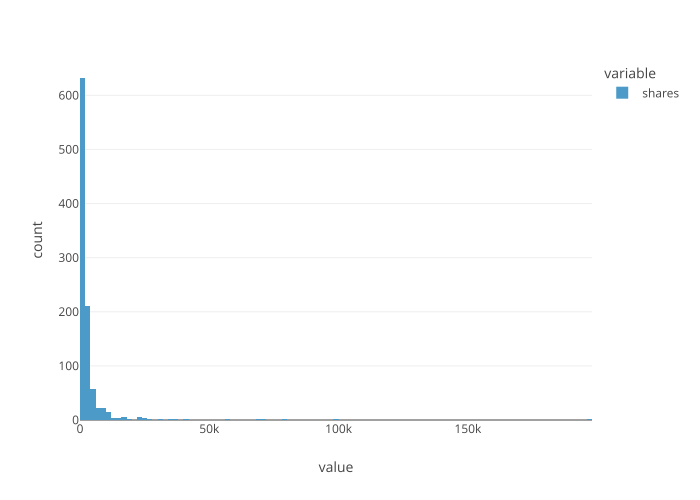

In [24]:
fig = px.histogram(dataset["shares"])
fig.show()

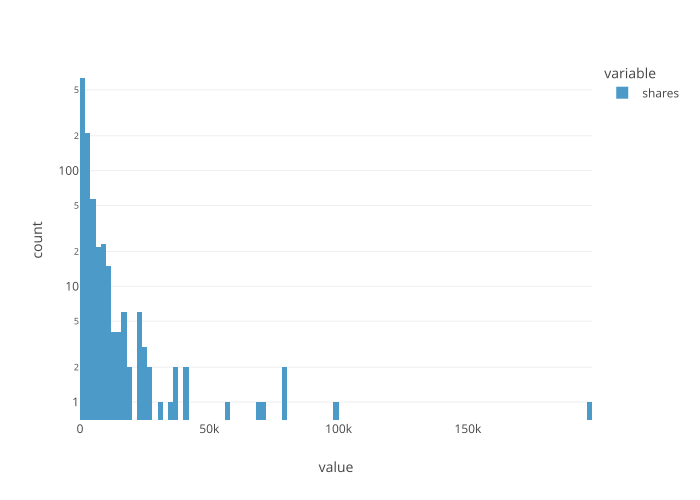

In [25]:
fig = px.histogram(dataset["shares"], log_y=True)
fig.show()

The graph of the target variable's distribution indicates that the disribution is extremely skewed, very few very high values are present which would cause our data to be extremely hard to model. Therefore we need to exclude from the dataset the rows where Y takes extremely high values. In this type of situation it is common to convert the target variable to a logarithmic scale.

2.bis Create a dataframe containing the explanatory variables and another one containing only the target variable, which is the number of shares. Convert y to logarithmic scale using np.log10

In [26]:
explanatory_df = dataset.iloc[:, :-1]
target_df = dataset.iloc[:, -1:]

In [27]:
target_df= np.log10(target_df)
target_df.head()

,shares
27187,3.716003
2277,3.361728
18309,3.518514
15731,3.342423
11849,3.716003


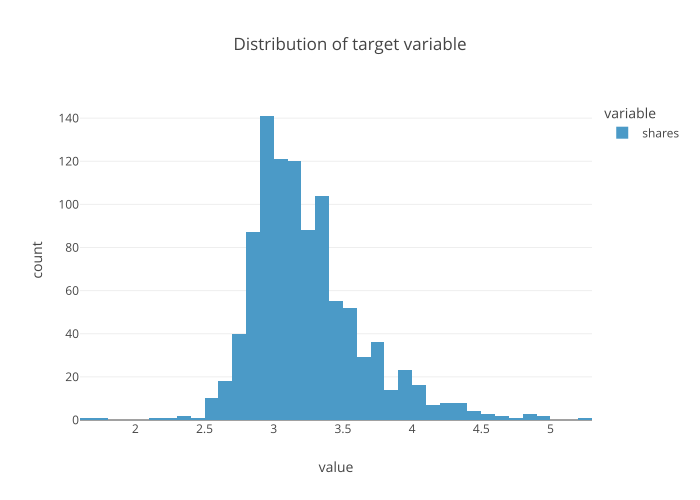

In [30]:
fig3 = px.histogram(target_df, title="Distribution of target variable")
fig3.show()

In [31]:
explanatory_df.head()

,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,avg_positive_polarity,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity
27187,205.0,12.0,1349.0,0.339059,0.425668,51.0,3.0,33.0,1.0,4.851742,...,0.409268,0.050000,1.0,-0.225513,-0.8,-0.076923,0.475000,0.150000,0.025000,0.150000
2277,693.0,10.0,554.0,0.531760,0.700880,11.0,7.0,1.0,0.0,4.722022,...,0.437764,0.033333,1.0,-0.287778,-0.5,-0.155556,0.100000,0.000000,0.400000,0.000000
18309,369.0,13.0,751.0,0.427793,0.578475,12.0,1.0,1.0,0.0,4.482024,...,0.291251,0.050000,0.6,-0.193155,-0.6,-0.050000,0.382143,0.139286,0.117857,0.139286
15731,428.0,12.0,1207.0,0.478898,0.664804,29.0,0.0,1.0,0.0,4.706711,...,0.400437,0.033333,1.0,-0.250309,-0.6,-0.100000,0.500000,0.500000,0.000000,0.500000
11849,505.0,13.0,329.0,0.616564,0.765000,5.0,2.0,0.0,1.0,5.130699,...,0.321488,0.136364,0.5,-0.243333,-0.5,-0.050000,0.000000,0.000000,0.500000,0.000000


2bis. Produce a list giving the indices of all couples of variables that are correlated above 90%

In [35]:
corr_matrix = dataset.corr().round(2)
corr_matrix

,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
timedelta,1.00,-0.21,-0.08,0.24,0.21,0.03,0.03,0.01,-0.01,0.14,...,0.06,0.11,-0.03,0.00,-0.04,0.02,0.03,-0.04,0.06,-0.04
n_tokens_title,-0.21,1.00,-0.00,-0.05,-0.05,-0.11,-0.04,0.02,0.05,-0.12,...,-0.02,-0.06,0.04,-0.03,0.06,0.06,-0.00,-0.12,0.01,0.04
n_tokens_content,-0.08,-0.00,1.00,-0.44,-0.25,0.41,0.27,0.31,0.08,0.14,...,-0.29,0.39,-0.15,-0.45,0.22,-0.01,-0.02,0.01,-0.01,-0.01
n_unique_tokens,0.24,-0.05,-0.44,1.00,0.93,-0.14,-0.04,-0.24,0.01,0.62,...,0.40,0.12,-0.15,0.08,-0.29,0.03,0.03,-0.06,0.00,0.02
n_non_stop_unique_tokens,0.21,-0.05,-0.25,0.93,1.00,-0.14,-0.02,-0.28,-0.03,0.66,...,0.29,0.25,-0.19,-0.05,-0.21,0.00,0.02,-0.05,-0.03,0.00
num_hrefs,0.03,-0.11,0.41,-0.14,-0.14,1.00,0.29,0.22,0.22,0.22,...,-0.09,0.24,-0.15,-0.23,0.04,0.09,0.02,-0.02,0.09,0.06
num_self_hrefs,0.03,-0.04,0.27,-0.04,-0.02,0.29,1.00,0.22,0.05,0.13,...,-0.07,0.16,-0.07,-0.10,0.01,-0.02,0.00,0.02,-0.02,0.02
num_imgs,0.01,0.02,0.31,-0.24,-0.28,0.22,0.22,1.00,-0.05,0.04,...,-0.04,0.16,-0.05,-0.12,0.06,-0.03,-0.05,0.04,-0.04,0.06
num_videos,-0.01,0.05,0.08,0.01,-0.03,0.22,0.05,-0.05,1.00,0.00,...,0.00,0.11,-0.13,-0.12,0.02,0.05,0.02,-0.07,0.08,-0.01
average_token_length,0.14,-0.12,0.14,0.62,0.66,0.22,0.13,0.04,0.00,1.00,...,0.18,0.43,-0.30,-0.23,-0.20,-0.03,-0.01,-0.02,-0.04,-0.01


In [40]:
seuil = 0.9
#Conservation de la partie triangualire supérieure de la matrice. k=1 exclut la diagonale, k=0 inclut la diag, k=-1 inclut la ligne dessous diag
corr_matrix_tri = np.triu(corr_matrix, k=1)
mask_sup = corr_matrix_tri > seuil
mask_sup

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [46]:
positions = np.where(mask_sup) # position retourne un tableau pour pos 0 pour les llinges ou true, pos1 pour col=true
print("Indices des corrélations fortes :", list(zip(positions[0], positions[1])))
var_list = []
for i, j in zip(positions[0], positions[1]):
    var1 = corr_matrix.index[i]
    var2 = corr_matrix.columns[j]
    # valeur = corr_matrix.iloc[i, j]
    var_list.append((var1, var2))

print(var_list)

Indices des corrélations fortes : [(np.int64(3), np.int64(4)), (np.int64(18), np.int64(19)), (np.int64(26), np.int64(28))]
[('n_unique_tokens', 'n_non_stop_unique_tokens'), ('kw_max_min', 'kw_avg_min'), ('self_reference_min_shares', 'self_reference_avg_sharess')]


In [ ]:
#Correction autre methode jedha
# corr = X.corr()

# high_corr_list = []
# cols = corr.columns

# for j in cols:
#     for i, item in corr[j].iteritems():
#         if (i!=j) and abs(item) > 0.9:
#             high_corr_list.append((i,j))
# high_corr_list

[('n_non_stop_unique_tokens', 'n_unique_tokens'),
 ('n_unique_tokens', 'n_non_stop_unique_tokens'),
 ('kw_avg_min', 'kw_max_min'),
 ('kw_max_min', 'kw_avg_min'),
 ('self_reference_avg_sharess', 'self_reference_min_shares'),
 ('self_reference_min_shares', 'self_reference_avg_sharess')]

2ter. Remove from X all variables that are correlated above 90%. Create an object X_clean that only contains the variables you would like to keep.

In [52]:
explanatory_df.columns

Index(['timedelta', 'n_tokens_title', 'n_tokens_content', 'n_unique_tokens',
       'n_non_stop_unique_tokens', 'num_hrefs', 'num_self_hrefs', 'num_imgs',
       'num_videos', 'average_token_length', 'num_keywords',
       'data_channel_is_lifestyle', 'data_channel_is_entertainment',
       'data_channel_is_bus', 'data_channel_is_socmed', 'data_channel_is_tech',
       'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min',
       'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg',
       'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares',
       'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday',
       'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday',
       'weekday_is_saturday', 'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04',
       'global_subjectivity', 'global_sentiment_polarity',
       'global_rate_positive_words', 'global_rate_negative_words',
       'rate_negative_words', 'avg_positive_polarity',

In [ ]:
# no_keep = [high_corr_list[i][0] for i in range(len(high_corr_list)) if i%2 == 0]
# print("Columns to be dropped:", no_keep)
# columns_to_keep = [c for c in X.columns if c not in no_keep]
# X_clean = X.loc[:, columns_to_keep]
useless_cols2 = ["n_non_stop_unique_tokens", "kw_avg_min", "self_reference_min_shares"]
X_clean = explanatory_df.drop(useless_cols2, axis=1)

In [56]:
X_clean

,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,num_keywords,...,avg_positive_polarity,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity
27187,205.0,12.0,1349.0,0.339059,51.0,3.0,33.0,1.0,4.851742,9.0,...,0.409268,0.050000,1.0,-0.225513,-0.8000,-0.076923,0.475000,0.150000,0.025000,0.150000
2277,693.0,10.0,554.0,0.531760,11.0,7.0,1.0,0.0,4.722022,4.0,...,0.437764,0.033333,1.0,-0.287778,-0.5000,-0.155556,0.100000,0.000000,0.400000,0.000000
18309,369.0,13.0,751.0,0.427793,12.0,1.0,1.0,0.0,4.482024,10.0,...,0.291251,0.050000,0.6,-0.193155,-0.6000,-0.050000,0.382143,0.139286,0.117857,0.139286
15731,428.0,12.0,1207.0,0.478898,29.0,0.0,1.0,0.0,4.706711,10.0,...,0.400437,0.033333,1.0,-0.250309,-0.6000,-0.100000,0.500000,0.500000,0.000000,0.500000
11849,505.0,13.0,329.0,0.616564,5.0,2.0,0.0,1.0,5.130699,7.0,...,0.321488,0.136364,0.5,-0.243333,-0.5000,-0.050000,0.000000,0.000000,0.500000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28155,190.0,11.0,185.0,0.557377,13.0,1.0,12.0,0.0,4.362162,7.0,...,0.450000,0.200000,0.7,-0.183333,-0.2000,-0.166667,1.000000,0.250000,0.500000,0.250000
18490,366.0,11.0,596.0,0.479592,22.0,1.0,21.0,0.0,4.750000,10.0,...,0.384037,0.100000,0.8,-0.298721,-0.9000,-0.071429,0.250000,-0.083333,0.250000,0.083333
44,731.0,9.0,1022.0,0.427427,20.0,20.0,20.0,0.0,4.746575,8.0,...,0.419441,0.100000,1.0,-0.222917,-0.5000,-0.050000,0.000000,0.000000,0.500000,0.000000
5254,637.0,9.0,306.0,0.564460,16.0,1.0,1.0,0.0,4.656863,9.0,...,0.435119,0.166667,1.0,-0.197756,-0.3125,-0.050000,0.500000,0.500000,0.000000,0.500000


In [57]:
X_clean.columns

Index(['timedelta', 'n_tokens_title', 'n_tokens_content', 'n_unique_tokens',
       'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos',
       'average_token_length', 'num_keywords', 'data_channel_is_lifestyle',
       'data_channel_is_entertainment', 'data_channel_is_bus',
       'data_channel_is_socmed', 'data_channel_is_tech',
       'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_min_max',
       'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg', 'kw_avg_avg',
       'self_reference_max_shares', 'self_reference_avg_sharess',
       'weekday_is_monday', 'weekday_is_tuesday', 'weekday_is_wednesday',
       'weekday_is_thursday', 'weekday_is_friday', 'weekday_is_saturday',
       'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity',
       'global_sentiment_polarity', 'global_rate_positive_words',
       'global_rate_negative_words', 'rate_negative_words',
       'avg_positive_polarity', 'min_positive_polarity',
       'max_positive_polarity', 'avg_negative

3. Are the different variables in your dataset on the same scale ? Verify this by using the describe method.

In [80]:
X_clean.describe(include="all")

,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,num_keywords,...,avg_positive_polarity,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,350.293000,10.484000,540.058000,0.533191,10.799000,3.19400,4.570000,1.24000,4.567762,7.206000,...,0.359513,0.100505,0.764513,-0.254494,-0.510839,-0.102380,0.277957,0.069438,0.353569,0.152021
std,212.748695,2.092396,465.540633,0.129250,11.115402,3.39085,8.918556,4.55754,0.767052,1.882314,...,0.104204,0.078553,0.239552,0.119911,0.285152,0.083702,0.331816,0.268229,0.185251,0.231603
min,9.000000,5.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,1.000000,...,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000
25%,165.000000,9.000000,241.750000,0.473558,4.000000,1.00000,1.000000,0.00000,4.488171,6.000000,...,0.306473,0.050000,0.600000,-0.319729,-0.700000,-0.125000,0.000000,0.000000,0.186458,0.000000
50%,328.500000,10.000000,408.500000,0.538990,7.000000,3.00000,1.000000,0.00000,4.646244,7.000000,...,0.363016,0.100000,0.800000,-0.250000,-0.500000,-0.100000,0.066667,0.000000,0.500000,0.000000
75%,532.000000,12.000000,701.500000,0.610862,13.000000,4.00000,4.000000,1.00000,4.842102,9.000000,...,0.416875,0.100000,1.000000,-0.187500,-0.300000,-0.050000,0.500000,0.136364,0.500000,0.250000
max,731.000000,17.000000,5530.000000,0.967742,159.000000,34.00000,99.000000,75.00000,5.894330,10.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.500000,1.000000


3bis. Use the `train_test_split` command from the `sklearn.model_selection` package to create a training sample containing 70% of the observations and a test sample containing 30% of the observations. Make sure to have used the data you just cleaned.

In [64]:
X_train, X_test, Y_train, Y_test = train_test_split(X_clean, target_df, test_size=0.3, random_state=0)

3ter. Is it important to normalize data before training a regularized model? If yes normalize your data.

In [65]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

4. Train a non-regularized linear regression model. Are the performances satisfying?

In [ ]:
# Train model
print("Train model...")
regressor = LinearRegression()
regressor.fit(X_train, Y_train)
print("...Done.")
Y_train_pred = regressor.predict(X_train)
Y_test_pred = regressor.predict(X_test)
print("R2 score on training set : ", r2_score(Y_train, Y_train_pred))
print("R2 score on test set : ", r2_score(Y_test, Y_test_pred))
# # Print R^2 scores
# print("R2 score on training set : ", regressor.score(X_train, y_train))
# print("R2 score on test set : ", regressor.score(X_test, y_test))

Train model...
...Done.
R2 score on training set :  0.15605002412157365
R2 score on test set :  0.009025701933156882


5. What could you do to improve the quality of the model?

We have R2test ​<< R2train​ : the model is overfitting!

6. Train a Ridge model by making a grid search to find the optimal value of $\alpha$. Try values from 0 to 1000 with a step of 10, use a value of 10 as the "cv" parameter and a value of 1 for the "verbose" parameter.

In [72]:
alpha = np.arange(0, 1010, 10)
alpha

array([   0,   10,   20,   30,   40,   50,   60,   70,   80,   90,  100,
        110,  120,  130,  140,  150,  160,  170,  180,  190,  200,  210,
        220,  230,  240,  250,  260,  270,  280,  290,  300,  310,  320,
        330,  340,  350,  360,  370,  380,  390,  400,  410,  420,  430,
        440,  450,  460,  470,  480,  490,  500,  510,  520,  530,  540,
        550,  560,  570,  580,  590,  600,  610,  620,  630,  640,  650,
        660,  670,  680,  690,  700,  710,  720,  730,  740,  750,  760,
        770,  780,  790,  800,  810,  820,  830,  840,  850,  860,  870,
        880,  890,  900,  910,  920,  930,  940,  950,  960,  970,  980,
        990, 1000])

In [76]:
# Perform grid search
print("Grid search...")
regressor = Ridge()
# Grid of values to be tested
params = {
    'alpha': np.arange(0, 1000, 10) # 0 corresponds to no regularization
}
gridsearch = GridSearchCV(regressor, param_grid = params, cv = 10, verbose=1) # cv : the number of folds to be used for CV
gridsearch.fit(X_train, Y_train)
print("...Done.")
print("Best hyperparameters : ", gridsearch.best_params_)
print("Best R2 score : ", gridsearch.best_score_)

Grid search...
Fitting 10 folds for each of 100 candidates, totalling 1000 fits
...Done.
Best hyperparameters :  {'alpha': np.int64(780)}
Best R2 score :  0.03816741336681062


7. What is the score on the test set obtained using this optimal alpha parameter?

In [77]:
regressor = Ridge(alpha=780)
regressor.fit(X_train, Y_train)
print("R2 score on training set : ", regressor.score(X_train, Y_train))
print("R2 score on test set : ", regressor.score(X_test, Y_test))

R2 score on training set :  0.09663826205982617
R2 score on test set :  0.12187770616576299


8. Is the test R2 **significantly** different from the train R2? Use cross-validation to answer.

In [78]:
scores = cross_val_score(regressor, X_train, Y_train, cv=3)
print('The cross-validated R2-score is : ', scores.mean())
print('The standard deviation is : ', scores.std())

The cross-validated R2-score is :  0.015205997021147851
The standard deviation is :  0.03843619498022266


Conclusion

The cross-validation shows that the scores can typically vary by ±0.03±0.03. This means that there's actually an uncertainty on the scores:

R2train = 0.13 ± 0.03

R2test = 0.07 ± 0.03

By taking into account these uncertainties, we can conclude that there's no significant difference anymore between the performances on train and test set, which means we have tackled the overfitting problem.

The output of this exercise isn't very satisfying, because we can also notice that in the end, the test R2-score is almost zero, meaning that the model's predictive power is hardly better than a dummy model!

Actually, the overfitting problem occured because we had to many features compared to the very low number of rows in the dataset (we kept only 1000 rows). To check that, you can go back to question 0bis. and comment the line :

# data = data.sample(1000, random_state = 1)

If you train again the linear regression model, you'll see that the overfitting has disappeared 🤓